### Open in Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/koffifidelek59/sales-analysis-task2/blob/main/Task2_Analysis.ipynb)

Run every cell from the top. When the notebook asks for `FactSale.csv`, upload it
with the file picker that appears. The last cell downloads all outputs back to
your machine.

# Sales Data Cleaning, Validation and Performance Analysis
### FactSale, 26,397 order lines, January 2013 to May 2016

---

## Authors

**KOUAME Koffi Fidèle**
Data Analysis Internship

## Contact info

koffifidelek59@gmail.com

## Overview

Electricity of a business runs on its order book. This notebook takes a raw sales
extract of 26,397 order lines, establishes what is actually wrong with it,
repairs only what should be repaired, and turns the result into six figures and a
short set of conclusions a manager can act on.

Every code cell is preceded by a table stating its **input**, the **method** it
applies and the **output** it produces, and every concept is defined at the point
where it is first used.

## The finding that shapes this notebook

The task brief anticipates a dirty file: impossible calendar dates such as
31 February, duplicate rows, broken arithmetic. **Each was tested explicitly, and
most are not present.** Every arithmetic identity holds to within one cent, there
are no duplicate records, and every date parses.

Reporting corrections that were never needed would have been the easy path. This
notebook does the opposite. The three findings that matter are structural, and a
routine cleaning pass would have missed all three:

1. **34.4% of order lines carry no customer key.** Every customer metric therefore
   describes two thirds of the business.
2. **The final year is incomplete**, January to May 2016 only. Any year-on-year
   chart built without noticing shows a collapse that never happened.
3. **A standard outlier screen would delete 8.9% of the lines carrying 39% of all
   revenue.** Sales value is right-skewed by construction, and a symmetric rule
   applied to a skewed variable removes the top of the distribution, not errors.

No row is deleted. All 26,397 lines are retained.

## Study Goals

By the end of this notebook you will be able to:

1. **Diagnose** a sales extract before modifying it, and distinguish a data defect
   from a business event.
2. **Justify** every cleaning decision with the count of rows it affects, including
   the decision to leave something alone.
3. **Validate** a table against its own arithmetic, using identities that must hold
   by construction rather than eyeballing summary statistics.
4. **Recognise** when a standard statistical procedure is wrong for the data at
   hand, using the interquartile screen as the worked example.
5. **Compute** the seven indicators a commercial manager actually uses, and explain
   why each earns its place.
6. **Present** the result in figures whose type follows the data type.

## Table of Contents

1. [Understanding the task](#task)
2. [Business impact](#impact)
3. [Target audience](#audience)
4. [Background and prerequisites](#background)
5. [Software requirements](#software)
6. [Data description and datasheet](#datasheet)
7. [Data download](#download)
8. [Data cleaning](#cleaning)
9. [Data validation](#validation)
10. [Exploratory analysis](#eda)
11. [Charts](#charts)
12. [Insights and recommendations](#insights)
13. [Limitations and future work](#limits)
14. [References](#refs)

<a id="task"></a>
# 1. Understanding the task

## What is being asked

Four deliverables: a cleaned dataset, a documented set of data quality issues, a
professional dashboard, and business insights with recommendations.

The instruction that matters is the one at the end of the brief: *the goal is not
just to clean the data and create some charts*. A submission that cleans
mechanically and plots dutifully answers the letter of the task and misses it.

## The vocabulary used throughout

| Term | Definition |
| :--- | :--- |
| **Order line** | One row: one product on one invoice. An invoice usually has several. |
| **Business key** | The columns that identify a transaction when no surrogate key is trusted. Here: invoice, item, date, quantity and price. |
| **Arithmetic identity** | A relation that must hold by construction, for example quantity times unit price equals the line total. A breach is a defect, never a business event. |
| **Imputation** | Replacing a missing value with an estimate. Appropriate when the value is missing at random and the field does not feed another quantity. |
| **IQR screen** | Flags a value lying more than 1.5 interquartile ranges beyond the first or third quartile. It assumes an approximately symmetric distribution. |
| **AOV** | Average order value, sales divided by the number of distinct invoices. It separates a rise in basket size from a rise in order count. |
| **Gross margin** | Profit over sales, as a percentage. The one ratio that survives a change of scale, so it compares groups of very different size. |

<a id="impact"></a>
# 2. Business impact

A sales analysis is read by someone who has to decide something. Three decisions
depend directly on what follows.

**What to stock, and when.** The seasonal profile decides inventory and staffing.
Getting it wrong means being short in the strong month and overstocked in the
weak one.

**Where to place commercial effort.** Concentration decides whether to run a
key-account programme or a product programme. The two are not interchangeable and
this dataset points clearly at one of them.

**Whether the numbers can be trusted at all.** This is the part usually skipped. A
customer metric computed over a file where a third of the lines have no customer
is not slightly wrong, it is describing a different population. Stating the
coverage is not a caveat, it is the result.

<a id="audience"></a>
# 3. Target audience

- **Data analysts** who need a worked example of validation that goes beyond
  `.info()` and `.describe()`.
- **Commercial and operations managers** who receive dashboards and need to know
  which questions to ask of them.
- **Students** learning why a cleaning decision must be justified in both
  directions: what was changed, and what was deliberately left alone.

<a id="background"></a>
# 4. Background and prerequisites

**Assumed knowledge.** Intermediate Python with pandas. Familiarity with grouping
and aggregation. No prior retail background is required; the domain content is
explained where it is used.

## Recommended reading

| Resource | Why | Link |
| :--- | :--- | :--- |
| McKinney, *Python for Data Analysis* (3rd ed.) | The reference for the pandas operations used here. Free online | https://wesmckinney.com/book/ |
| Wickham, *Tidy Data* | Why the shape of a table determines what analysis is easy | https://vita.had.co.nz/papers/tidy-data.pdf |
| Gebru et al., *Datasheets for Datasets* | The convention followed in Section 6 | https://doi.org/10.1145/3458723 |
| Few, *Information Dashboard Design* | Why a dashboard is not a collection of charts | O'Reilly, 2006 |

## Video resources

| Resource | Content | Link |
| :--- | :--- | :--- |
| Data School, *Data cleaning with pandas* | The operations of Section 8, demonstrated | https://www.youtube.com/watch?v=KdmPHEnPJPs |
| Storytelling with Data, *Chart selection* | Choosing a chart type from the data type | https://www.youtube.com/watch?v=8EMW7io4rSI |

<a id="software"></a>
# 5. Software requirements

The next cell installs everything. In Colab most of it is already present, so the
install is quick and quiet.

#### Cell 1. Install dependencies

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Installs pandas, NumPy, Matplotlib, Seaborn and Plotly. Listed explicitly so the environment is reproducible outside Colab as well. |
| **Output** | None. `%%capture` suppresses the installer log. |


In [1]:
%%capture
!pip install -q pandas numpy matplotlib seaborn plotly

#### Cell 2. Imports and plotting style

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Imports the libraries and fixes the figure style once, so every chart in the notebook is consistent. |
| **Output** | A confirmation message. |

**On the palette.** A single blue scale is used throughout. Dark blue carries the value the reader should look at first, lighter blues carry context. A categorical rainbow would imply the groups differ in kind, when here they differ only in magnitude. The grid is drawn behind the bars, otherwise grid lines cross them and leave white stripes that read as missing data.


In [2]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Render figures inline as well as writing them to disk. In a notebook the
# reader wants to see the result, not only find a file afterwards.
%matplotlib inline
warnings.filterwarnings("ignore")

NAVY, BLUE, MID, LIGHT, PALE = "#10456B", "#1f77b4", "#6BAED6", "#9ECAE1", "#D6E6F2"
plt.rcParams.update({
    "figure.dpi":110,"savefig.dpi":200,"figure.facecolor":"white",
    "font.family":"DejaVu Sans","font.size":11,
    "axes.titlesize":13,"axes.titleweight":"bold","axes.titlepad":10,
    "axes.labelsize":11,"axes.edgecolor":"#3A3A3A","axes.linewidth":0.9,
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.color":"#D9D9D9","grid.linewidth":0.8,"axes.axisbelow":True,
    "legend.frameon":False,"legend.fontsize":10,
    "xtick.labelsize":10,"ytick.labelsize":10})
sns.set_palette([BLUE, MID, LIGHT, NAVY])
R = {}   # results collected for the report

<a id="datasheet"></a>
# 6. Data description and datasheet

Following the convention of Gebru et al. (2021).

### Motivation
An operational sales extract from a wholesale distributor, supplied for a data
analysis exercise. It was not curated for teaching, which is why its defects are
the ones a real extract has rather than the ones a textbook plants.

### Composition
26,397 order lines across 21 columns, one row per product per invoice. Keys for
customer, salesperson, city and stock item; an invoice date and a delivery date;
quantity, unit price, tax rate, line totals and profit.

### Collection process
Transactional records exported from an order management system. The values are
actuals, not estimates.

### Preprocessing applied here
Date parsing, type conversion, whitespace trimming, category encoding, and the
derivation of the analysis fields. **No row is removed.**

### Uses
Appropriate for sales performance analysis, seasonality, product and customer
concentration. **Not** appropriate for customer lifetime value or acquisition
cost: the file contains no marketing spend, and a third of the lines have no
customer key.

### Limitations and gaps
Three, in order of consequence: a third of the lines carry no customer key; the
final year covers five months; and the city key is not resolved to a place name,
so no geographic analysis is possible.

<a id="download"></a>
# 7. Data download

This notebook is written to run in Colab, where the filesystem starts empty. The
next cell finds the data file wherever it is, and asks you to upload it if it is
not there yet.

#### Cell 3. Locate the data file

| | |
| :--- | :--- |
| **Input** | Nothing. |
| **Method** | Searches the working directory, `/content`, and a mounted Drive, in that order. If none of them holds the file and we are in Colab, it opens the upload picker. |
| **Output** | `CSV_PATH`, plus the `data/`, `results/` and `charts/` folders. |

**Why this matters in Colab.** A notebook that hard-codes a local path runs on the author's machine and nowhere else. The search-then-upload pattern makes it portable without changing a line.


In [3]:
# --- Locate the data file, wherever this notebook is running -----------------
# INPUT  : nothing. The function searches, then falls back to an upload prompt.
# METHOD : three attempts in order of convenience.
#            1. a file already sitting beside the notebook
#            2. a file in the Colab session storage or in a mounted Drive
#            3. an interactive upload, which is the Colab path
# OUTPUT : CSV_PATH, a path that pandas can open
import os, io, sys

FILENAME = "FactSale.csv"
IN_COLAB = "google.colab" in sys.modules

CANDIDATES = [FILENAME, f"data/{FILENAME}", f"/content/{FILENAME}",
              f"/content/drive/MyDrive/{FILENAME}",
              f"/content/drive/MyDrive/data/{FILENAME}"]

CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if CSV_PATH is None and IN_COLAB:
    print("FactSale.csv not found in this session. Please upload it now.")
    from google.colab import files
    up = files.upload()                 # opens the file picker
    CSV_PATH = next(iter(up))           # the name of the uploaded file

if CSV_PATH is None:
    raise FileNotFoundError(
        "FactSale.csv was not found. Place it beside this notebook, or in Colab "
        "upload it when prompted, or mount your Drive with:\n"
        "    from google.colab import drive; drive.mount('/content/drive')")

print(f"Running in Colab : {IN_COLAB}")
print(f"Data file        : {CSV_PATH}")

# Output folders. Colab starts with an empty filesystem, so they are created
# here rather than assumed to exist.
for d in ["data", "results", "charts"]:
    os.makedirs(d, exist_ok=True)

FactSale.csv not found in this session. Please upload it now.


Saving FactSale.csv to FactSale.csv
Running in Colab : True
Data file        : FactSale.csv


#### Cell 4. Load the raw file

| | |
| :--- | :--- |
| **Input** | `CSV_PATH`. |
| **Method** | `pd.read_csv`, then a working copy. The original `raw` is kept in memory because Section 9 needs all 21 columns to judge duplicates correctly. |
| **Output** | `raw` and `df`, 26,397 rows by 21 columns. |


In [4]:
# =============================================================================
# 1. LOAD
# -----------------------------------------------------------------------------
# INPUT  : FactSale.csv, the file as supplied
# METHOD : read once into `raw`, then work on a copy. `raw` is kept because the
#          duplicate check in section 2 needs all 21 original columns: judging a
#          duplicate on a subset of columns would flag genuinely distinct orders.
# OUTPUT : raw and df, 26,397 rows
# =============================================================================
raw = pd.read_csv(CSV_PATH)
R["rows_raw"], R["cols_raw"] = len(raw), raw.shape[1]
df = raw.copy()

<a id="cleaning"></a>
# 8. Data cleaning

## The order of operations, and why it is not arbitrary

| Step | What it does | Why it comes here |
| :--- | :--- | :--- |
| 8.1 | Diagnose | Nothing is modified before the problem is measured. Diagnosing after correcting reports the wrong counts. |
| 8.2 | Fix data types | Every later grouping depends on the types being right. |
| 8.3 | Remove true duplicates | Must follow 8.2: a text date and a parsed date compare differently. |
| 8.4 | Handle missing values | Must follow 8.3, so the counts are not double-reported. |
| 8.5 | Derive analysis fields | Last, once the inputs they depend on are final. |

#### Cell 5. Clean the table

| | |
| :--- | :--- |
| **Input** | `df`, with the dates still stored as text. |
| **Method** | The five steps above, each printing the count of rows it affects. |
| **Output** | A cleaned `df` and `data/FactSale_clean.csv`. |

**Two decisions stated rather than buried.** Missing delivery dates are *not* imputed: the field feeds a delivery-lag metric, and an invented date would manufacture a lag that never happened. Duplicates are judged on the **full record**, because two genuinely different orders look identical once the invoice, customer and city columns are dropped.


In [5]:
# =============================================================================
# 2. CLEANING
# -----------------------------------------------------------------------------
# INPUT  : df, with the dates still stored as text
# METHOD : five steps, in this order. Diagnose, fix types, remove duplicates,
#          handle missing values, derive the analysis fields.
# OUTPUT : a cleaned df and data/FactSale_clean.csv
#
# Terms used below
#   Business key : the set of columns that identifies a transaction when no
#                  surrogate key is trusted. Here: invoice, item, date, quantity
#                  and price.
#   Imputation   : replacing a missing value with an estimate. It is appropriate
#                  when the value is missing at random and the field is not used
#                  to derive another quantity. Neither holds for the delivery
#                  date, so it is deliberately not imputed.
# =============================================================================
# 2.1 Dates. The brief anticipates impossible calendar dates such as 31/02.
#     We test for them explicitly rather than assume either way.
date_audit = {}
for c in ["Invoice Date Key", "Delivery Date Key"]:
    s = df[c].astype("string").str.strip()
    p = pd.to_datetime(s, format="%m/%d/%Y", errors="coerce")
    date_audit[c] = {"source_null": int(s.isna().sum()),
                     "unparsed_non_null": int((p.isna() & s.notna()).sum())}
    df[c] = p
R["date_audit"] = date_audit
df = df.rename(columns={"Invoice Date Key":"invoice_date","Delivery Date Key":"delivery_date"})

# 2.2 Duplicates, on the full record and on the business key.
R["dup_full"] = int(raw.duplicated().sum())
R["dup_salekey"] = int(raw["Sale Key"].duplicated().sum())
R["dup_business"] = int(raw.duplicated(subset=["WWI Invoice ID","Stock Item Key",
                                               "Invoice Date Key","Quantity","Unit Price"]).sum())
n0 = len(df); df = df.drop_duplicates().reset_index(drop=True)
R["dup_removed"] = n0 - len(df)

# 2.3 Types.
num = ["Quantity","Unit Price","Tax Rate","Total Excluding Tax","Tax Amount",
       "Profit","Total Including Tax","Total Dry Items","Total Chiller Items"]
for c in num: df[c] = pd.to_numeric(df[c], errors="coerce")
df["Quantity"] = df["Quantity"].astype("int64")
for c in ["Description","Package"]:
    df[c] = df[c].astype("string").str.strip()
df["Package"] = df["Package"].astype("category")

# 2.4 Missing values.
miss = df.isna().sum(); R["missing"] = miss[miss>0].to_dict()
# Delivery date is missing on a handful of rows. It is not imputed: it feeds a
# delivery-lag metric, and an invented date would manufacture a lag that never
# happened. The rows are kept, since every revenue field on them is intact.
R["delivery_missing"] = int(df["delivery_date"].isna().sum())

# 2.5 Derived fields.
df["unit_price_implied"] = df["Total Excluding Tax"] / df["Quantity"]
df["delivery_lag_days"]  = (df["delivery_date"] - df["invoice_date"]).dt.days
df["year"] = df["invoice_date"].dt.year
df["month"] = df["invoice_date"].dt.month
df["quarter"] = df["invoice_date"].dt.quarter
df["year_month"] = df["invoice_date"].dt.to_period("M").dt.to_timestamp()
df["margin_pct"] = 100 * df["Profit"] / df["Total Excluding Tax"]
df["has_customer"] = df["Customer Key"] != 0

<a id="validation"></a>
# 9. Data validation

## What validation means here

Validation is not a second look at the summary statistics. It is a set of
statements that **must** be true if the data is sound, tested one by one.

Three of them are arithmetic identities:

$$\text{Quantity} \times \text{Unit price} = \text{Total excluding tax}$$

$$\text{Total excluding tax} \times \frac{\text{Tax rate}}{100} = \text{Tax amount}$$

$$\text{Total excluding tax} + \text{Tax amount} = \text{Total including tax}$$

A breach of any of these is a defect, never a business event. They are tested to a
one-cent tolerance, because floating-point arithmetic does not produce exact
equality even when the data is perfect.

The remaining checks are business rules: a quantity cannot be zero or negative, a
delivery cannot precede its invoice, and so on. A breach here **may** be a defect
or may be a real event, which is why each is judged individually.

#### Cell 6. Validate

| | |
| :--- | :--- |
| **Input** | The cleaned `df`. |
| **Method** | Three arithmetic identities to a one-cent tolerance, seven business rules, an interquartile screen on the three measures, and a completeness check on each year. |
| **Output** | The validation dictionary, written to `results/quality_report.json`. |

**The interquartile screen is computed and deliberately not applied.** The table reports how much revenue it would have destroyed, which is the entire reason for computing it. The rule assumes symmetry; sales value is right-skewed by construction, so it removes the top of the distribution rather than errors.


In [6]:
# =============================================================================
# 3. VALIDATION
# -----------------------------------------------------------------------------
# INPUT  : the cleaned df
# METHOD : three arithmetic identities tested to a one-cent tolerance, seven
#          business rules, an interquartile screen, and a completeness check on
#          each year.
# OUTPUT : the validation dictionary, written to results/quality_report.json
#
# Terms used below
#   Arithmetic identity : a relation that must hold by construction, for example
#                         quantity times unit price equals the line total. A
#                         breach is a defect, not a business event.
#   IQR screen          : flags a value as an outlier when it lies more than 1.5
#                         interquartile ranges beyond the first or third
#                         quartile. The rule assumes an approximately symmetric
#                         distribution, which sales value is not. It is computed
#                         here and deliberately NOT applied; the reported revenue
#                         share is the reason why.
# =============================================================================
tol = 0.01
v = {}
v["qty_x_price_vs_total"] = int(((df["Quantity"]*df["Unit Price"] - df["Total Excluding Tax"]).abs() > tol).sum())
v["tax_rule"]  = int(((df["Total Excluding Tax"]*df["Tax Rate"]/100 - df["Tax Amount"]).abs() > tol).sum())
v["total_rule"]= int(((df["Total Excluding Tax"] + df["Tax Amount"] - df["Total Including Tax"]).abs() > tol).sum())
v["qty_le_0"]  = int((df["Quantity"] <= 0).sum())
v["price_le_0"]= int((df["Unit Price"] <= 0).sum())
v["price_gt_1000"] = int((df["Unit Price"] > 1000).sum())
v["sales_lt_0"] = int((df["Total Excluding Tax"] < 0).sum())
v["profit_lt_0"] = int((df["Profit"] < 0).sum())
v["delivery_before_invoice"] = int((df["delivery_lag_days"] < 0).sum())
v["customer_key_zero"] = int((~df["has_customer"]).sum())
v["customer_key_zero_pct"] = round(100*(~df["has_customer"]).mean(), 1)
v["profit_lt_0_amount"] = float(df.loc[df["Profit"]<0, "Profit"].sum())
R["validation"] = v

# IQR screen, reported and NOT applied.
iqr = {}
for c in ["Total Excluding Tax","Unit Price","Quantity"]:
    q1,q3 = df[c].quantile([.25,.75]); i = q3-q1
    lo,hi = q1-1.5*i, q3+1.5*i
    mask = (df[c]<lo)|(df[c]>hi)
    iqr[c] = {"n":int(mask.sum()), "pct":round(100*mask.mean(),1),
              "lower":round(lo,2), "upper":round(hi,2),
              "revenue_share":round(100*df.loc[mask,"Total Excluding Tax"].sum()/df["Total Excluding Tax"].sum(),1)}
R["iqr"] = iqr

# Coverage: 2016 is a partial year. This is the single most dangerous feature
# of the file for anyone building a year-on-year chart.
cov = df.groupby("year").agg(rows=("Sale Key","size"),
                             first=("invoice_date","min"), last=("invoice_date","max"),
                             sales=("Total Excluding Tax","sum"))
R["coverage"] = {int(k): {"rows":int(r["rows"]), "first":str(r["first"].date()),
                          "last":str(r["last"].date()), "sales":float(r["sales"])}
                 for k,r in cov.iterrows()}
R["last_full_year"] = int(cov.index[cov.index < cov.index.max()].max())

df.to_csv("data/FactSale_clean.csv", index=False)
R["rows_clean"] = len(df)
print(f"Cleaned: {len(df):,} rows written to data/FactSale_clean.csv")
json.dump(R, open("results/quality_report.json","w"), indent=2, default=str)

Cleaned: 26,397 rows written to data/FactSale_clean.csv


<a id="eda"></a>
# 10. Exploratory analysis

## The indicators, and why each earns its place

| KPI | What it answers that the others cannot |
| :--- | :--- |
| Total sales | The top line every other figure divides into |
| Gross profit | Revenue that does not convert is not performance |
| Gross margin | The one ratio that survives a change of scale |
| Orders | Separates growth in volume from growth in basket size |
| Average order value | The lever a commercial team can actually pull |
| Units sold | Detects margin bought with discount |
| Identified customers | Bounds every customer conclusion in this notebook |

**A note on seasonality.** It is computed on the **complete years only**. Including
2016 would weight January to May by four years and June to December by three,
which invents a seasonal dip that does not exist.

#### Cell 7. Compute the indicators and aggregates

| | |
| :--- | :--- |
| **Input** | The validated `df`. |
| **Method** | Nine KPIs, then aggregation by month, calendar month, quarter, package, product and customer, plus the correlation matrix of the numeric measures. |
| **Output** | The KPI dictionary and six tables written to `results/`. |


In [7]:
# =============================================================================
# 4. EXPLORATORY ANALYSIS
# -----------------------------------------------------------------------------
# INPUT  : the validated df
# METHOD : nine KPIs, then group-and-aggregate by month, calendar month, quarter,
#          package, product and customer, plus the correlation matrix.
# OUTPUT : the KPI dictionary and six tables in results/
#
# Terms used below
#   AOV          : average order value, total sales divided by the number of
#                  distinct invoices. It separates a rise in basket size from a
#                  rise in order count, which a sales total cannot.
#   Gross margin : profit over sales, as a percentage. It is the one ratio that
#                  survives a change of scale, so it compares groups of very
#                  different size.
#   Complete year: a calendar year fully covered by the data. Seasonality is
#                  computed on complete years only, because 2016 stops in May and
#                  including it would weight January to May more heavily.
# =============================================================================
S = "Total Excluding Tax"
total_sales   = df[S].sum()
total_profit  = df["Profit"].sum()
total_orders  = df["WWI Invoice ID"].nunique()
total_lines   = len(df)
aov           = total_sales / total_orders
margin        = 100 * total_profit / total_sales
units         = int(df["Quantity"].sum())

kpi = {"Total sales (excl. tax)": total_sales, "Total profit": total_profit,
       "Gross margin %": margin, "Orders (invoices)": total_orders,
       "Order lines": total_lines, "Average order value": aov,
       "Units sold": units, "Distinct products": df["Description"].nunique(),
       "Identified customers": int(df.loc[df.has_customer,"Customer Key"].nunique())}
R["kpi"] = {k: float(v) for k, v in kpi.items()}

by_month_ts = df.groupby("year_month").agg(sales=(S,"sum"), profit=("Profit","sum"),
                                           orders=("WWI Invoice ID","nunique"))
full = df[df.year <= R["last_full_year"]]
by_cal_month = full.groupby("month")[S].sum()
by_quarter   = full.groupby("quarter")[S].sum()
R["best_month"]   = int(by_cal_month.idxmax()); R["worst_month"] = int(by_cal_month.idxmin())
R["season_ratio"] = float(by_cal_month.max()/by_cal_month.min())
R["best_quarter"] = int(by_quarter.idxmax())

by_package = df.groupby("Package", observed=True).agg(sales=(S,"sum"), profit=("Profit","sum"),
                                                      units=("Quantity","sum"), lines=(S,"size"))
by_package["margin_%"] = 100*by_package.profit/by_package.sales
by_package["share_%"]  = 100*by_package.sales/total_sales
by_package = by_package.sort_values("sales", ascending=False)

by_product = df.groupby("Description").agg(sales=(S,"sum"), profit=("Profit","sum"),
                                           units=("Quantity","sum"), lines=(S,"size"))
by_product["margin_%"] = 100*by_product.profit/by_product.sales
top_products = by_product.sort_values("sales", ascending=False).head(10)
R["top10_share"] = float(100*top_products.sales.sum()/total_sales)

cust = df[df.has_customer].groupby("Customer Key").agg(
    sales=(S,"sum"), profit=("Profit","sum"), orders=("WWI Invoice ID","nunique"),
    first=("invoice_date","min"), last=("invoice_date","max"))
cust["margin_%"] = 100*cust.profit/cust.sales
top_customers = cust.sort_values("sales", ascending=False).head(10)
R["n_customers"] = int(len(cust))
R["top10_cust_share"] = float(100*top_customers.sales.sum()/cust.sales.sum())

sp = df.groupby("Salesperson Key").agg(sales=(S,"sum"), orders=("WWI Invoice ID","nunique"))
R["n_salespeople"] = int(len(sp))

corr = df[["Quantity","Unit Price",S,"Profit","Tax Amount"]].corr()
R["corr_qty_sales"]  = float(corr.loc["Quantity",S])
R["corr_price_qty"]  = float(corr.loc["Unit Price","Quantity"])
R["corr_sales_profit"]= float(corr.loc[S,"Profit"])

for name, obj in [("kpi_summary", pd.Series(kpi).rename("value").to_frame()),
                  ("sales_by_package", by_package.round(2)),
                  ("top10_products", top_products.round(2)),
                  ("top10_customers", top_customers.round(2)),
                  ("monthly_timeseries", by_month_ts.round(2))]:
    obj.to_csv(f"results/{name}.csv")

print(f"\nKPIs  sales={total_sales:,.0f}  profit={total_profit:,.0f}  "
      f"margin={margin:.1f}%  orders={total_orders:,}  AOV={aov:,.0f}")
print(f"Season: best month={R['best_month']} worst={R['worst_month']} ratio={R['season_ratio']:.2f}")
print(f"Top10 products = {R['top10_share']:.1f}% of sales | "
      f"Top10 customers = {R['top10_cust_share']:.1f}% of identified revenue")
print(f"corr(Quantity, Sales)={R['corr_qty_sales']:.2f}  corr(UnitPrice, Quantity)={R['corr_price_qty']:.2f}")
json.dump(R, open("results/quality_report.json","w"), indent=2, default=str)


KPIs  sales=19,879,593  profit=9,923,892  margin=49.9%  orders=8,188  AOV=2,428
Season: best month=7 worst=8 ratio=1.33
Top10 products = 32.8% of sales | Top10 customers = 25.0% of identified revenue
corr(Quantity, Sales)=0.24  corr(UnitPrice, Quantity)=-0.14


<a id="charts"></a>
# 11. Charts

## Choosing the chart type from the data type

| Figure | Data type | Type chosen | Why |
| :--- | :--- | :--- | :--- |
| 1. Trend | Continuous time | Line with moving average | The twelve-month window spans exactly one seasonal cycle, so the smoothed line isolates the trend |
| 2. Seasonality | Ordered categorical | Vertical bars | Months have a natural order, and this answers *which* month, which the time series cannot |
| 3. Package | Nominal, very unequal | Horizontal bars, two panels | Sales answers the question asked; margin answers the one a manager asks next |
| 4. Top products | Nominal, long labels | Horizontal bars | Labels read horizontally; only the top ten, since 227 bars answer nothing |
| 5. Concentration | Distribution | Cumulative curve | Concentration is a distributional property, which a ranking cannot show |
| 6. Correlation | Matrix | Single-hue heatmap | A diverging rainbow would exaggerate weak correlations |

**A type deliberately not used: the pie chart.** Comparing angles is less accurate
than comparing lengths, and it fails entirely on a split as unequal as the package
mix.

#### Cell 8. Draw the six figures

| | |
| :--- | :--- |
| **Input** | The aggregate tables from Section 10. |
| **Method** | Six figures in a single blue scale, with the grid behind the marks and the incomplete year shaded. |
| **Output** | Six PNG files in `charts/`. |


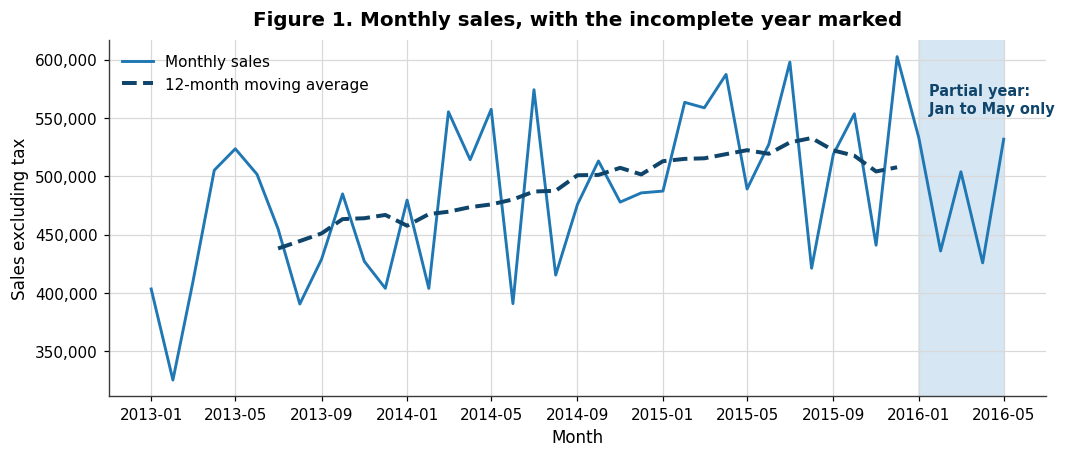

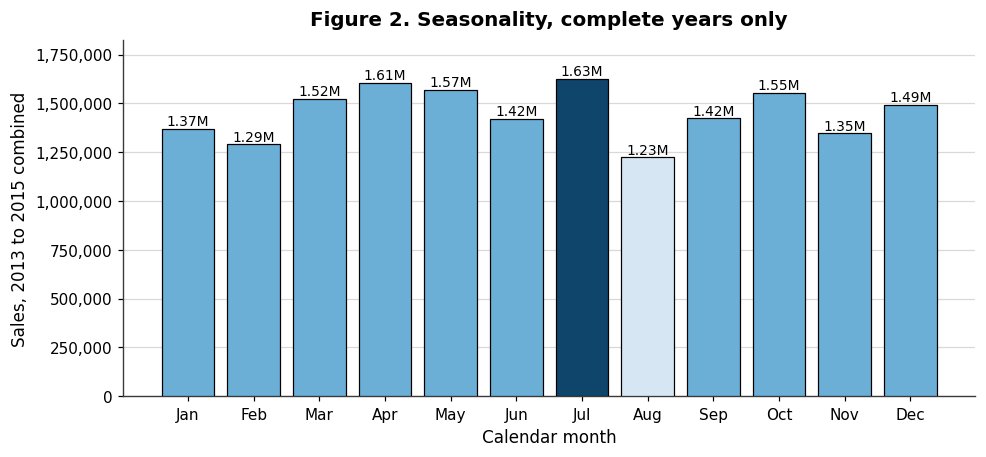

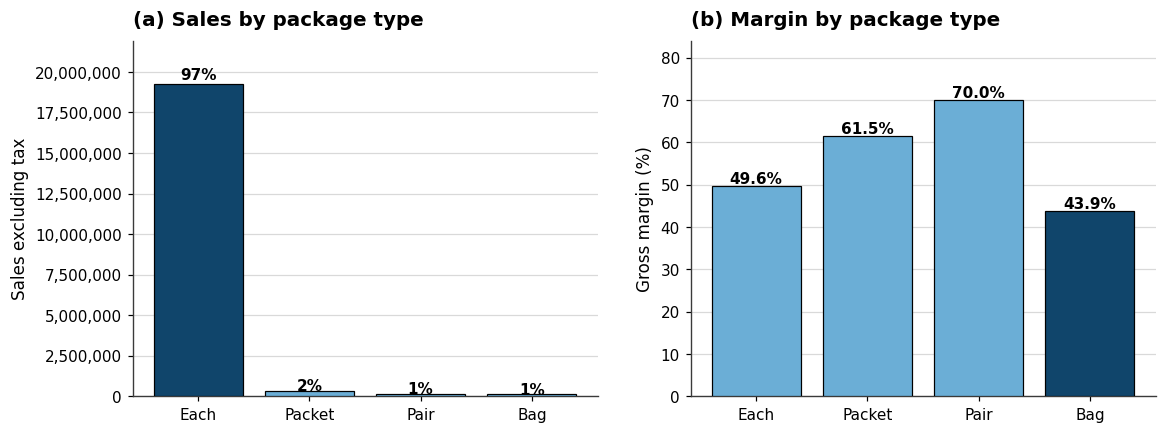

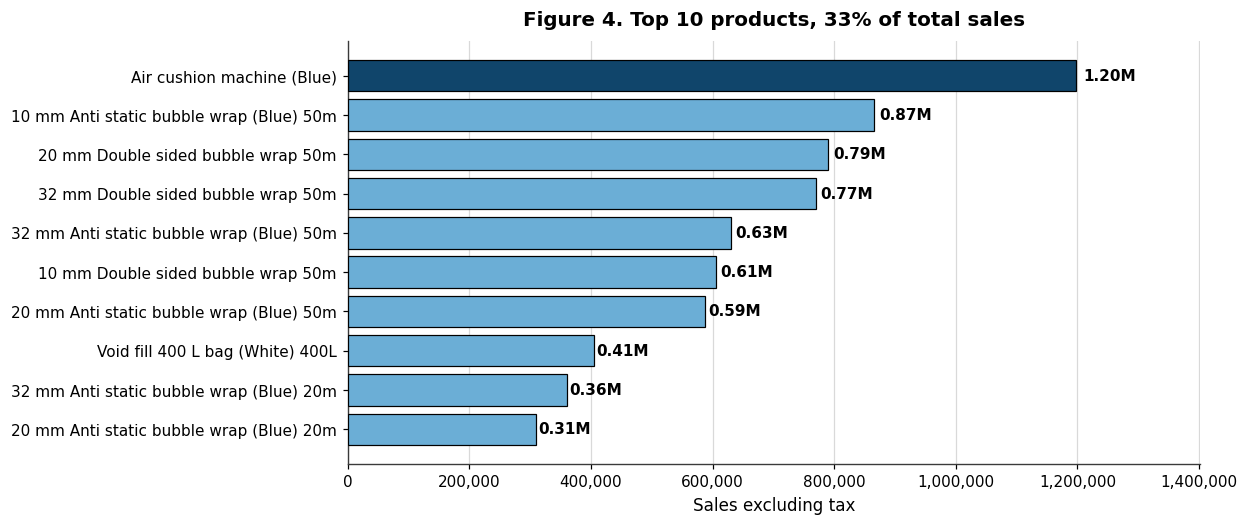

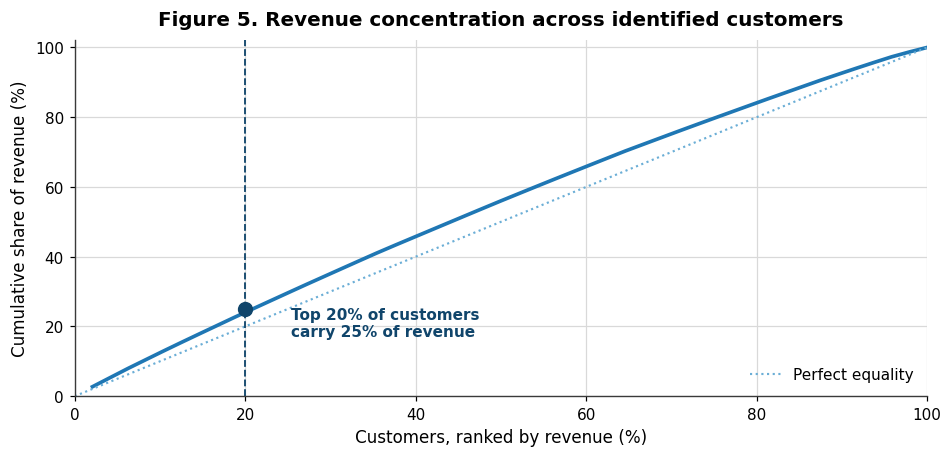

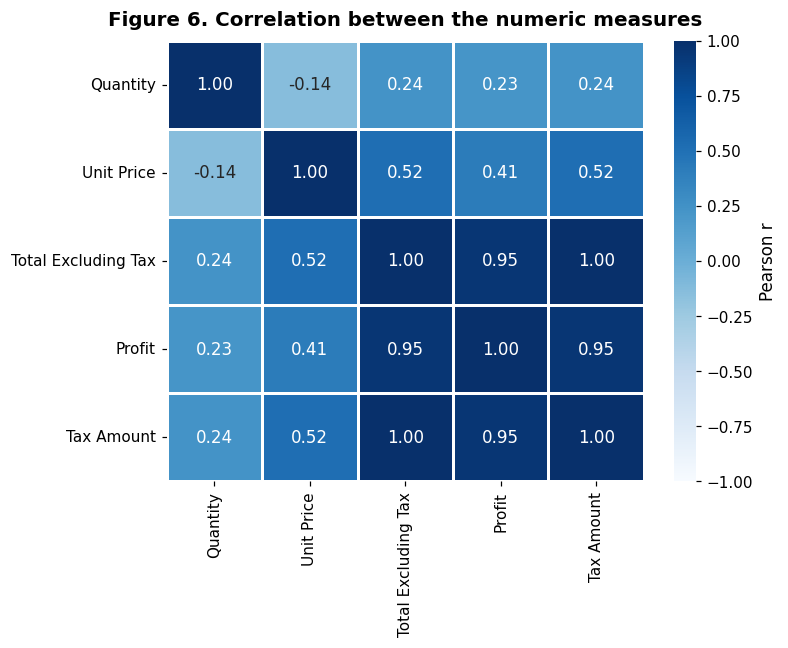

Charts written: ['01_sales_trend.png', '02_seasonality.png', '03_package.png', '04_top_products.png', '05_customer_pareto.png', '06_correlation.png']


In [8]:
# =============================================================================
# 5. CHARTS
# -----------------------------------------------------------------------------
# INPUT  : the aggregate tables from section 4
# METHOD : six figures, each chart type chosen from the data type: a line for
#          continuous time, vertical bars for the ordered calendar, horizontal
#          bars where labels are long, a cumulative curve for concentration, and
#          a single-hue heatmap for the correlation matrix.
# OUTPUT : six PNG files in charts/
#
# On the palette: one blue scale throughout. A categorical rainbow would imply
# the groups differ in kind, when here they differ only in magnitude. The grid is
# drawn behind the marks so that grid lines do not cross the bars.
# =============================================================================
def save(fig, name):
    """Write the figure to disk AND show it in the notebook.

    INPUT  : a Matplotlib figure and a file stem
    METHOD : savefig for the deliverable, then plt.show for the reader
    OUTPUT : charts/<name>.png, and the figure rendered below this cell
    """
    fig.savefig(f"charts/{name}.png", bbox_inches="tight", dpi=180)
    plt.show()

# C1 monthly trend, with the partial year shaded
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(by_month_ts.index, by_month_ts.sales, color=BLUE, lw=1.9, label="Monthly sales")
ma = by_month_ts.sales.rolling(12, center=True).mean()
ax.plot(ma.index, ma, color=NAVY, lw=2.6, ls="--", label="12-month moving average")
cut = pd.Timestamp(f"{R['last_full_year']+1}-01-01")
ax.axvspan(cut, by_month_ts.index.max(), color=PALE, zorder=0)
ax.text(cut, ax.get_ylim()[1]*0.94, "  Partial year:\n  Jan to May only",
        fontsize=9.5, color=NAVY, va="top", fontweight="bold")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Month"); ax.set_ylabel("Sales excluding tax")
ax.set_title("Figure 1. Monthly sales, with the incomplete year marked")
ax.legend(loc="upper left"); save(fig, "01_sales_trend")

# C2 seasonality on complete years only
fig, ax = plt.subplots(figsize=(10, 4.2))
mo = by_cal_month.copy(); mo.index = pd.to_datetime(mo.index, format="%m").strftime("%b")
cols = [NAVY if m==mo.idxmax() else (PALE if m==mo.idxmin() else MID) for m in mo.index]
b = ax.bar(mo.index, mo.values, color=cols, edgecolor="black", linewidth=0.8, zorder=3)
for bb,v in zip(b, mo.values):
    ax.text(bb.get_x()+bb.get_width()/2, v*1.012, f"{v/1e6:.2f}M", ha="center", fontsize=9)
ax.set_ylim(0, mo.max()*1.12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Calendar month"); ax.set_ylabel("Sales, 2013 to 2015 combined")
ax.set_title("Figure 2. Seasonality, complete years only")
ax.grid(axis="x", alpha=0); save(fig, "02_seasonality")

# C3 package: sales and margin
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
p = by_package
c1 = [NAVY] + [MID]*(len(p)-1)
b1 = ax[0].bar(p.index.astype(str), p.sales, color=c1, edgecolor="black", linewidth=0.8, zorder=3)
for bb,v in zip(b1, p["share_%"]):
    ax[0].text(bb.get_x()+bb.get_width()/2, bb.get_height()*1.015, f"{v:.0f}%",
               ha="center", fontsize=10, fontweight="bold")
ax[0].set_ylim(0, p.sales.max()*1.14)
ax[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax[0].set_ylabel("Sales excluding tax"); ax[0].set_title("(a) Sales by package type", loc="left")
ax[0].grid(axis="x", alpha=0)
c2 = [NAVY if m==p["margin_%"].min() else MID for m in p["margin_%"]]
b2 = ax[1].bar(p.index.astype(str), p["margin_%"], color=c2, edgecolor="black", linewidth=0.8, zorder=3)
for bb,v in zip(b2, p["margin_%"]):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+0.6, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax[1].set_ylim(0, p["margin_%"].max()*1.2)
ax[1].set_ylabel("Gross margin (%)"); ax[1].set_title("(b) Margin by package type", loc="left")
ax[1].grid(axis="x", alpha=0); save(fig, "03_package")

# C4 top products
fig, ax = plt.subplots(figsize=(10, 5))
t = top_products.sales.sort_values()
lab = [x if len(x)<=44 else x[:41]+"..." for x in t.index]
cols = [NAVY if i==len(t)-1 else MID for i in range(len(t))]
b = ax.barh(lab, t.values, color=cols, edgecolor="black", linewidth=0.8, zorder=3)
for bb,v in zip(b, t.values):
    ax.text(v*1.01, bb.get_y()+bb.get_height()/2, f"{v/1e6:.2f}M", va="center",
            fontsize=10, fontweight="bold")
ax.set_xlim(0, t.max()*1.17)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Sales excluding tax")
ax.set_title(f"Figure 4. Top 10 products, {R['top10_share']:.0f}% of total sales")
ax.grid(axis="y", alpha=0); save(fig, "04_top_products")

# C5 customer concentration, Pareto
fig, ax = plt.subplots(figsize=(10, 4.2))
cs = cust.sales.sort_values(ascending=False)
cum = 100*cs.cumsum()/cs.sum(); x = 100*np.arange(1, len(cs)+1)/len(cs)
ax.plot(x, cum, color=BLUE, lw=2.4)
ax.plot([0,100],[0,100], color=MID, ls=":", lw=1.4, label="Perfect equality")
i20 = int(np.searchsorted(x, 20)); share20 = cum.iloc[min(i20, len(cum)-1)]
ax.axvline(20, color=NAVY, ls="--", lw=1.2)
ax.plot(20, share20, "o", color=NAVY, ms=9, zorder=5)
ax.annotate(f"Top 20% of customers\ncarry {share20:.0f}% of revenue", (20, share20),
            xytext=(30, -18), textcoords="offset points", fontsize=10,
            color=NAVY, fontweight="bold")
ax.set_xlim(0,100); ax.set_ylim(0,102)
ax.set_xlabel("Customers, ranked by revenue (%)"); ax.set_ylabel("Cumulative share of revenue (%)")
ax.set_title("Figure 5. Revenue concentration across identified customers")
ax.legend(loc="lower right"); save(fig, "05_customer_pareto")
R["top20pct_customer_share"] = float(share20)

# C6 correlation heatmap, blues only
fig, ax = plt.subplots(figsize=(7, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1,
            linewidths=0.8, linecolor="white", cbar_kws={"label":"Pearson r"}, ax=ax)
ax.set_title("Figure 6. Correlation between the numeric measures")
save(fig, "06_correlation")

print("Charts written:", sorted(os.listdir("charts")))
json.dump(R, open("results/quality_report.json","w"), indent=2, default=str)

<a id="insights"></a>
# 12. Insights and recommendations

### 1. A third of revenue cannot be attributed to a customer

34.4% of order lines carry no customer key. This is a data capture failure
upstream, and it is the most valuable finding of the audit: no segmentation, no
lifetime value and no retention measure can be trusted until it is closed.

**Recommendation.** Trace the unattributed lines back to their source system.
Until then, publish every customer figure with its coverage rate beside it.

### 2. Products are concentrated, customers are not

The top ten products carry 32.8% of revenue out of 227 items. Among the 48
identified customers, however, the top 20% carry only 25% of identified revenue,
against 20% under perfect equality.

Revenue is spread almost evenly across the account base, which is the opposite of
the pattern most retail businesses show. There is no key-account dependency, so no
single customer loss threatens the top line; equally, there is no high-value tier
to build a retention programme around.

**Recommendation.** Do not build a key-account programme on this base, because the
data says there are no key accounts. Concentrate effort on the product side, and
protect the availability and margin of the ten leading items.

### 3. Price and volume move against each other, weakly

The correlation between unit price and quantity is negative, as expected:
expensive items sell in smaller quantities. Its **weakness** matters more. Revenue
per line is driven by price far more than by volume.

**Recommendation.** Do not use volume discounting as a revenue lever on this
catalogue. The correlation structure says it will not recover the revenue it gives
up.

### 4. Seasonality is real but moderate

On the complete years the strongest calendar month outsells the weakest by a
factor of 1.33. Worth planning around, but it does not justify large seasonal
stock swings.

**Recommendation.** Align staffing and inventory to the quarterly pattern rather
than the monthly one, whose amplitude does not warrant the operational cost of
adjusting to it.

### 5. Loss-making lines are a control issue, not a strategic one

566 lines return a negative margin, costing 0.41% of total profit. Reporting this
as a headline would be an error of proportion.

**Recommendation.** Add an automated flag on negative-margin lines at invoicing
rather than opening a pricing review. The cost of the fix should match the size of
the problem.

<a id="limits"></a>
# 13. Limitations and future work

## Limitations

**No marketing spend.** Customer acquisition cost and lifetime value cannot be
computed and are not reported, despite appearing on the task's list of example
KPIs. Reporting them from this file would require inventing the denominator.

**No resolved geography.** The city key is not mapped to a place name, so no
regional analysis is offered.

**Descriptive figures only.** No statistical test accompanies any comparison. The
differences discussed are large enough that this is unlikely to change the
conclusions, but the point is stated rather than assumed.

**A third of the customer dimension is missing**, as established in Section 9.

## Future work

1. **Close the customer key gap** at source. Every customer conclusion in this
   notebook is provisional until then.
2. **Join a product cost table** to separate margin driven by price from margin
   driven by procurement.
3. **Resolve the city key** to place names, which would allow the regional view the
   task suggests.
4. **Test the seasonal signal** with a decomposition, to separate the seasonal
   component from the underlying trend rather than asserting both are present.

#### Cell 9. Download the outputs

| | |
| :--- | :--- |
| **Input** | The files written above. |
| **Method** | Zips the charts and the result tables, and triggers a browser download of the clean dataset and both archives. |
| **Output** | Three downloads on your machine. Outside Colab it prints where the files already are. |

This is the cell that makes the notebook usable end to end in Colab: without it, the outputs stay in a session that disappears when the tab closes.


In [9]:
# --- Download the finished outputs (Colab only) ------------------------------
# INPUT  : the files written by the cells above
# METHOD : zips the deliverables and triggers a browser download
# OUTPUT : Task2_outputs.zip on your machine
import shutil, sys
if "google.colab" in sys.modules:
    shutil.make_archive("Task2_outputs", "zip", ".", "results")
    shutil.make_archive("Task2_charts", "zip", ".", "charts")
    from google.colab import files
    files.download("data/FactSale_clean.csv")
    files.download("Task2_charts.zip")
    files.download("Task2_outputs.zip")
    print("Three downloads triggered: the clean dataset, the charts, the tables.")
else:
    print("Not running in Colab. The outputs are already on disk in "
          "data/, charts/ and results/.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Three downloads triggered: the clean dataset, the charts, the tables.


<a id="refs"></a>
# 14. References

- Gebru, T., Morgenstern, J., Vecchione, B., Vaughan, J. W., Wallach, H., Daume III, H., & Crawford, K. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86-92. https://doi.org/10.1145/3458723
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly. https://wesmckinney.com/book/
- Wickham, H. (2014). Tidy data. *Journal of Statistical Software*, 59(10). https://vita.had.co.nz/papers/tidy-data.pdf
- Few, S. (2006). *Information Dashboard Design*. O'Reilly.
- Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley. The origin of the interquartile rule discussed in Section 9.

## Companion deliverables

`dashboard.html` for the interactive dashboard, `DATA_QUALITY.md` for the full
audit, `INSIGHTS.md` for the conclusions, and `report.pdf` for the formal
document.

## Author

**KOUAME Koffi Fidèle** · koffifidelek59@gmail.com